# CommittedAgent vs CommittedAgent — 2P3G Metrics

This notebook mirrors the structure of `analysis_adults_unified_claude.ipynb` for the current `n = 15` committed-vs-committed simulation.

Measures plotted:
- Success rate
- Commitment rate
- Efficiency
- Signaling

Definitions used here:
- Success: `collaborationSucceeded`
- Commitment: `finalReachedGoal == firstDetectedSharedGoal` on new-goal trials
- Efficiency: notebook-style per-agent post-new-goal trajectory efficiency
- Signaling: notebook-style first post-new-goal move toward reached goal but not toward the alternative goal


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

DATA_DIR = Path('committed_vs_committed_simulation')
RAW_FILES = [
    DATA_DIR / 'committed_vs_committed_2p3g_raw_trials_sessions_0_to_4.json',
    DATA_DIR / 'committed_vs_committed_2p3g_raw_trials_sessions_5_to_9.json',
    DATA_DIR / 'committed_vs_committed_2p3g_raw_trials_sessions_10_to_14.json',
]
for p in RAW_FILES:
    if not p.exists():
        raise FileNotFoundError(p)

DISTANCE_ORDER = ['closer_to_player1', 'equal_to_both', 'closer_to_player2', 'no_new_goal']
OVERALL_COLOR = '#4C78A8'
DISTANCE_PALETTE = {
    'closer_to_player1': '#E45756',
    'equal_to_both': '#54A24B',
    'closer_to_player2': '#4C78A8',
    'no_new_goal': '#9D9D9D',
}


In [2]:
def parse_trajectory(traj_value):
    if traj_value is None:
        return []
    if isinstance(traj_value, float) and np.isnan(traj_value):
        return []
    if isinstance(traj_value, list):
        traj = traj_value
    else:
        try:
            traj = json.loads(str(traj_value))
        except Exception:
            return []
    return [p for p in traj if isinstance(p, (list, tuple)) and len(p) == 2]

def remove_duplicates(traj):
    if len(traj) <= 1:
        return traj
    cleaned = [traj[0]]
    for i in range(1, len(traj)):
        if traj[i] != traj[i - 1]:
            cleaned.append(traj[i])
    return cleaned

def parse_point_str(value):
    if value is None:
        return None
    if isinstance(value, (list, tuple)) and len(value) == 2:
        return list(value)
    try:
        pt = json.loads(str(value))
    except Exception:
        return None
    return list(pt) if isinstance(pt, (list, tuple)) and len(pt) == 2 else None

def manhattan(p, q):
    return abs(int(p[0]) - int(q[0])) + abs(int(p[1]) - int(q[1]))

def compute_commitment(row):
    if not bool(row.get('newGoalPresented', False)):
        return np.nan
    shared_goal = row.get('firstDetectedSharedGoal')
    final_goal = row.get('player1FinalReachedGoal') if row.get('humanPlayerIndex', 0) == 0 else row.get('player2FinalReachedGoal')
    if pd.isna(shared_goal) or pd.isna(final_goal):
        return np.nan
    return 1 if int(shared_goal) == int(final_goal) else 0

def compute_efficiency(row):
    traj_col = 'player1Trajectory' if row.get('humanPlayerIndex', 0) == 0 else 'player2Trajectory'
    traj = remove_duplicates(parse_trajectory(row.get(traj_col)))
    if not traj:
        return np.nan
    try:
        idx = int(row.get('newGoalPresentedTime'))
    except Exception:
        return np.nan
    idx = max(0, min(idx, len(traj) - 1))
    actual_steps = (len(traj) - 1) - idx
    if actual_steps <= 0:
        return np.nan
    start = traj[idx]
    candidates = [parse_point_str(row.get('target1')), parse_point_str(row.get('target2')), parse_point_str(row.get('newGoalPosition'))]
    candidates = [g for g in candidates if g is not None]
    if not candidates:
        return np.nan
    optimal_steps = min(manhattan(start, g) for g in candidates)
    excess = actual_steps - optimal_steps
    eff = (1 - excess / actual_steps) * 100
    return max(0.0, min(100.0, eff))

def compute_signaling(row):
    if not bool(row.get('newGoalPresented', False)):
        return np.nan
    traj_col = 'player1Trajectory' if row.get('humanPlayerIndex', 0) == 0 else 'player2Trajectory'
    traj = remove_duplicates(parse_trajectory(row.get(traj_col)))
    if len(traj) < 2:
        return np.nan
    try:
        new_goal_time = int(row.get('newGoalPresentedTime'))
        final_goal_idx = int(row.get('player1FinalReachedGoal') if row.get('humanPlayerIndex', 0) == 0 else row.get('player2FinalReachedGoal'))
        shared_goal_idx = int(row.get('firstDetectedSharedGoal'))
    except Exception:
        return np.nan
    if new_goal_time < 0 or new_goal_time >= len(traj) - 1:
        return np.nan
    pos_before = traj[new_goal_time]
    pos_after = traj[new_goal_time + 1]
    target1 = parse_point_str(row.get('target1'))
    target2 = parse_point_str(row.get('target2'))
    new_goal = parse_point_str(row.get('newGoalPosition'))
    if target1 is None or target2 is None or new_goal is None:
        return np.nan
    if shared_goal_idx in (0, 1):
        old_idx_set = {0, 1}
        new_idx_set = {2}
        shared_goal = target1 if shared_goal_idx == 0 else target2
        other_old = target2 if shared_goal_idx == 0 else target1
    elif shared_goal_idx in (1, 2):
        old_idx_set = {1, 2}
        new_idx_set = {3}
        shared_goal = target1 if shared_goal_idx == 1 else target2
        other_old = target2 if shared_goal_idx == 1 else target1
    else:
        return np.nan
    if final_goal_idx in new_idx_set:
        reached_goal = new_goal
        other_goal = shared_goal
    elif final_goal_idx == shared_goal_idx:
        reached_goal = shared_goal
        other_goal = new_goal
    elif final_goal_idx in old_idx_set and final_goal_idx != shared_goal_idx:
        reached_goal = other_old
        other_goal = new_goal
    else:
        return np.nan
    moved_closer_to_reached = manhattan(pos_after, reached_goal) < manhattan(pos_before, reached_goal)
    moved_closer_to_other = manhattan(pos_after, other_goal) < manhattan(pos_before, other_goal)
    return 1 if moved_closer_to_reached and not moved_closer_to_other else 0

def participant_level(df, value_col):
    return df.dropna(subset=[value_col]).groupby(['participantId', 'distanceCondition'], as_index=False)[value_col].mean()

def mean_ci(series):
    vals = pd.Series(series).dropna().astype(float)
    n = len(vals)
    if n == 0:
        return {'mean': np.nan, 'ci_lower': np.nan, 'ci_upper': np.nan, 'n': 0}
    mean = vals.mean()
    se = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
    ci = 1.96 * se
    return {'mean': mean, 'ci_lower': mean - ci, 'ci_upper': mean + ci, 'n': n}


In [3]:
records = []
for raw_file in RAW_FILES:
    records.extend(json.loads(raw_file.read_text()))

base = pd.DataFrame(records)
print('Trial rows:', len(base))

long_rows = []
for row in base.to_dict(orient='records'):
    for human_index in (0, 1):
        long_rows.append({
            **row,
            'participantId': row['participantId_player1'] if human_index == 0 else row['participantId_player2'],
            'humanPlayerIndex': human_index,
            'partnerType': 'commitAgent',
        })

df = pd.DataFrame(long_rows)
df['successRate'] = df['collaborationSucceeded'].astype(int)
df['commitment'] = df.apply(compute_commitment, axis=1)
df['efficiencyPercent'] = df.apply(compute_efficiency, axis=1)
df['signalingMove'] = df.apply(compute_signaling, axis=1)

df_new_goal = df[df['newGoalPresented'] == True].copy()
df_new_goal_success = df_new_goal[df_new_goal['collaborationSucceeded'] == True].copy()

print('Participant rows:', len(df))
print('Unique participants:', df['participantId'].nunique())
print('New-goal participant rows:', len(df_new_goal))
print('Successful new-goal participant rows:', len(df_new_goal_success))


Trial rows: 180
Participant rows: 360
Unique participants: 30
New-goal participant rows: 270
Successful new-goal participant rows: 266


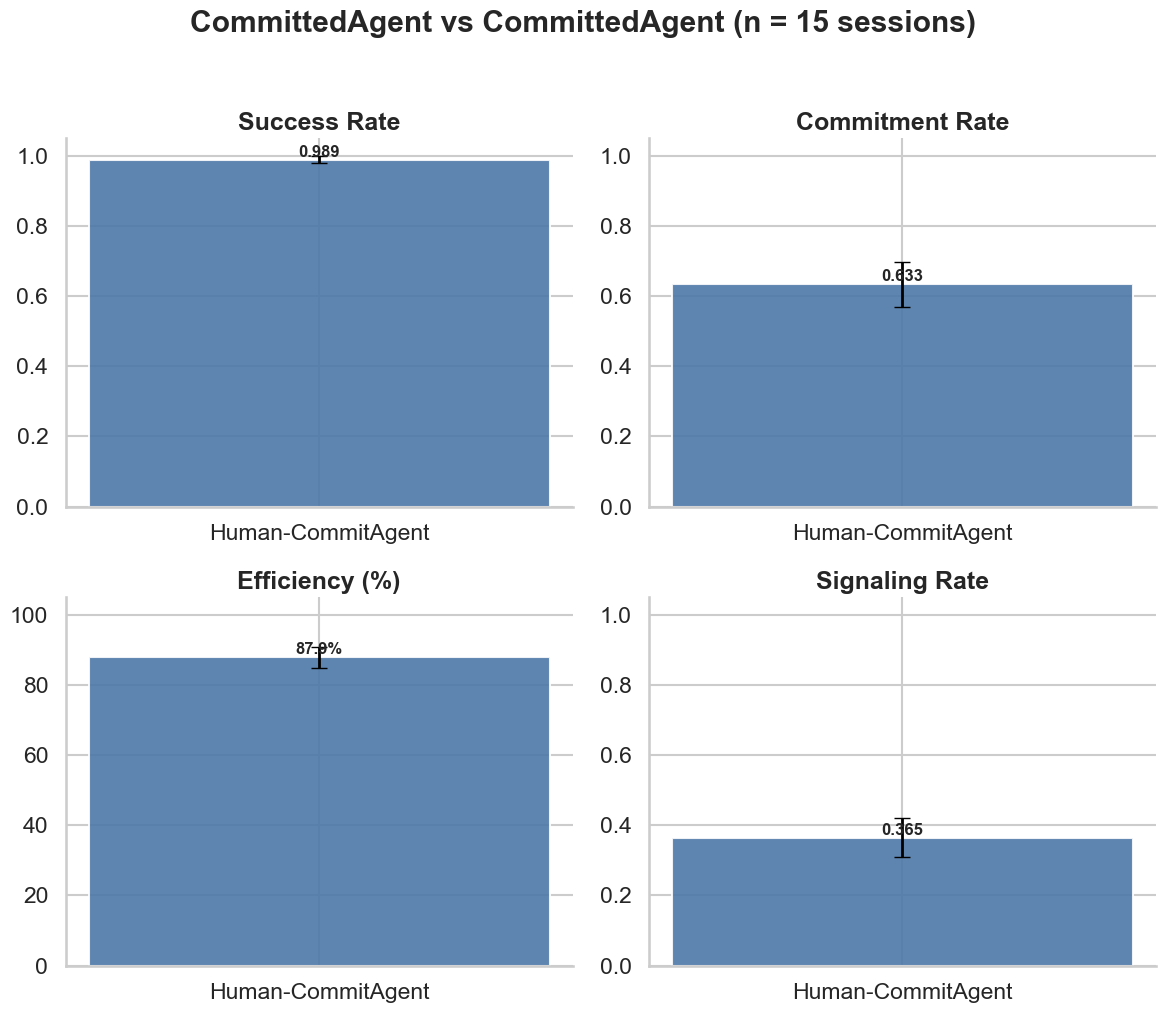

,measure,mean,ci_lower,ci_upper,n_participants
0,Success Rate,0.988889,0.978579,0.999199,30
1,Commitment Rate,0.633333,0.568000,0.698667,30
2,Efficiency (%),87.851333,84.925936,90.776729,30
3,Signaling Rate,0.364815,0.310200,0.419430,30


In [4]:
overall_metrics = {
    'Success Rate': mean_ci(df.groupby('participantId', as_index=False)['successRate'].mean()['successRate']),
    'Commitment Rate': mean_ci(df_new_goal.groupby('participantId', as_index=False)['commitment'].mean()['commitment']),
    'Efficiency (%)': mean_ci(df_new_goal_success.groupby('participantId', as_index=False)['efficiencyPercent'].mean()['efficiencyPercent']),
    'Signaling Rate': mean_ci(df_new_goal.groupby('participantId', as_index=False)['signalingMove'].mean()['signalingMove']),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, (label, stats) in zip(axes, overall_metrics.items()):
    mean = stats['mean']
    yerr = [[mean - stats['ci_lower']], [stats['ci_upper'] - mean]]
    ax.bar(['Human-CommitAgent'], [mean], color=OVERALL_COLOR, alpha=0.9)
    ax.errorbar([0], [mean], yerr=yerr, fmt='none', ecolor='black', elinewidth=2, capsize=6)
    fmt = '{:.1f}' if 'Efficiency' in label else '{:.3f}'
    suffix = '%' if 'Efficiency' in label else ''
    ax.text(0, mean, fmt.format(mean) + suffix, ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylim((0, 105) if 'Efficiency' in label else (0, 1.05))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('CommittedAgent vs CommittedAgent (n = 15 sessions)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

pd.DataFrame({
    'measure': list(overall_metrics.keys()),
    'mean': [v['mean'] for v in overall_metrics.values()],
    'ci_lower': [v['ci_lower'] for v in overall_metrics.values()],
    'ci_upper': [v['ci_upper'] for v in overall_metrics.values()],
    'n_participants': [v['n'] for v in overall_metrics.values()],
})


/var/folders/wb/_15vsjnj26j9fsl6zcs0cphw0000gn/T/ipykernel_13016/3269009657.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/wb/_15vsjnj26j9fsl6zcs0cphw0000gn/T/ipykernel_13016/3269009657.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/wb/_15vsjnj26j9fsl6zcs0cphw0000gn/T/ipykernel_13016/3269009657.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/wb/_15vsjnj26j9fsl6zcs0cphw0000gn/T/ipykernel_13016/3269009657.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

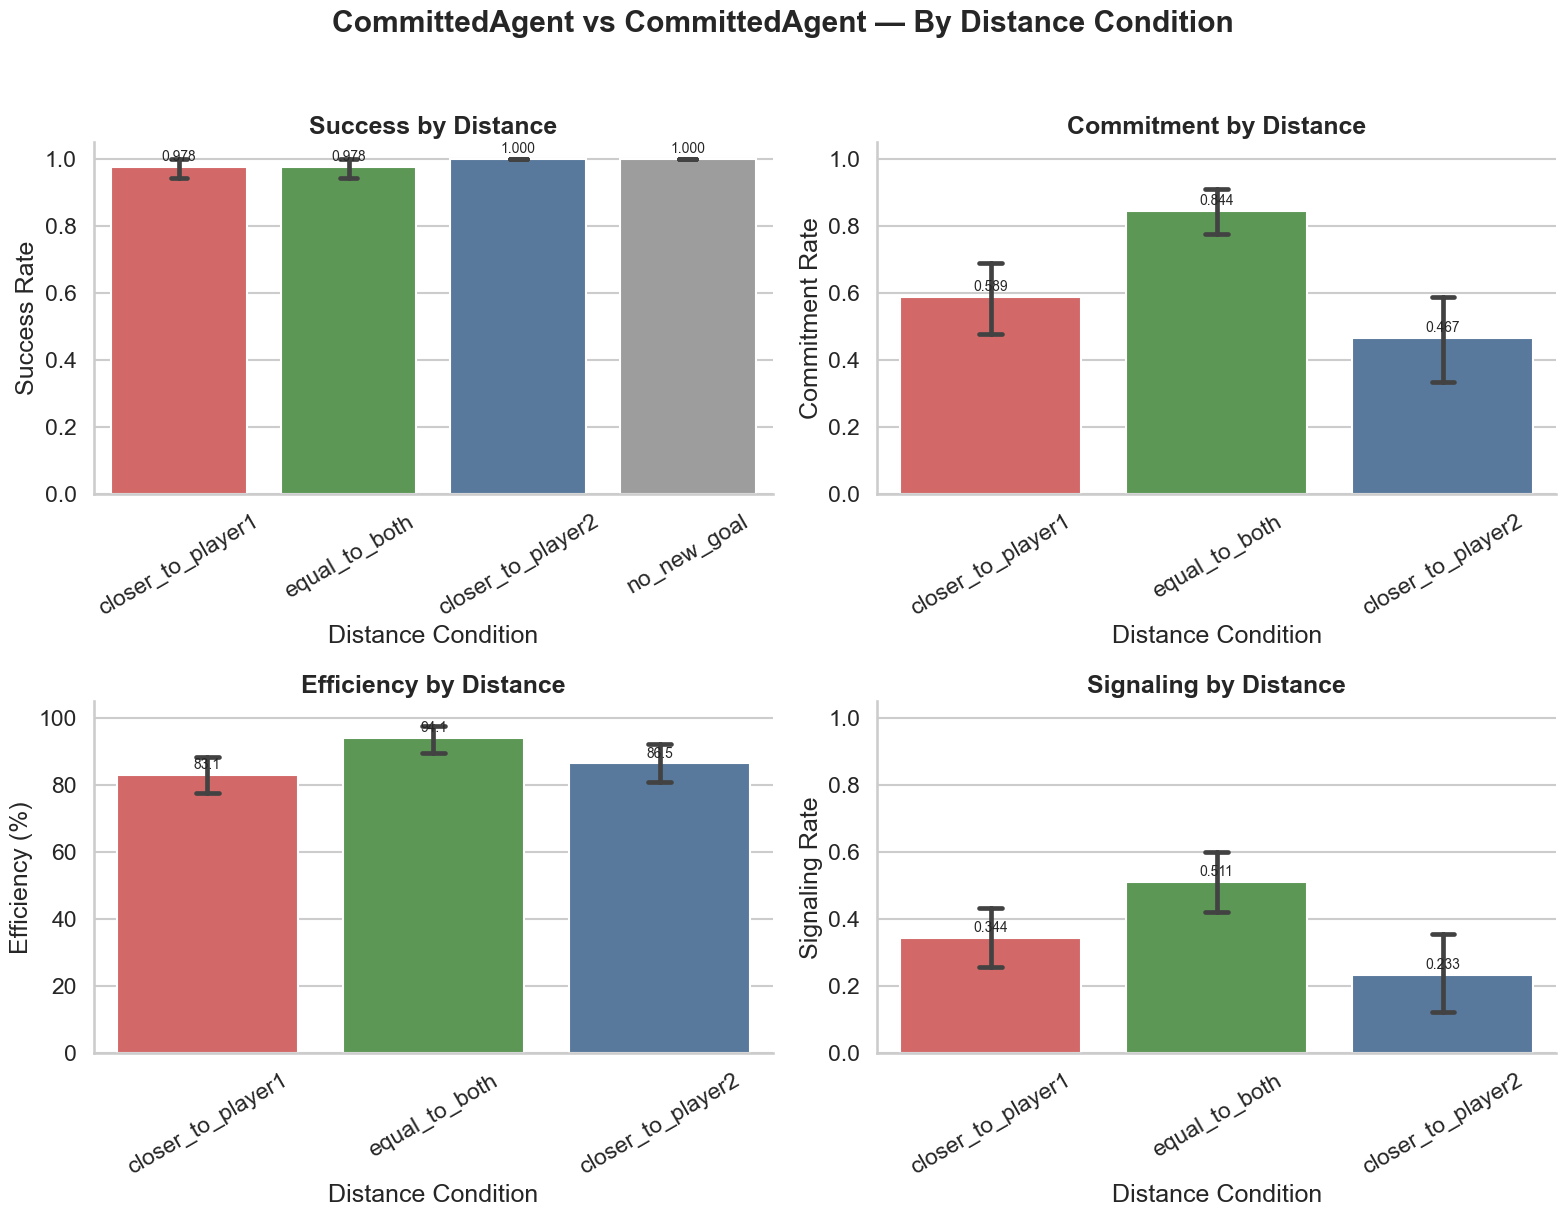

In [5]:
def plot_by_distance(ax, data, value_col, title, ylabel, ylim, include_no_new_goal=True):
    participant_means = data.dropna(subset=[value_col]).groupby(['participantId', 'distanceCondition'], as_index=False)[value_col].mean()
    order = DISTANCE_ORDER if include_no_new_goal else [d for d in DISTANCE_ORDER if d != 'no_new_goal']
    participant_means = participant_means[participant_means['distanceCondition'].isin(order)].copy()
    sns.barplot(
        data=participant_means,
        x='distanceCondition',
        y=value_col,
        order=order,
        palette=[DISTANCE_PALETTE[d] for d in order],
        errorbar=('ci', 95),
        capsize=0.1,
        ax=ax,
    )
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append('' if pd.isna(height) else (f'{height:.1f}' if 'Efficiency' in title else f'{height:.3f}'))
        ax.bar_label(container, labels=labels, padding=2, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Distance Condition')
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    ax.tick_params(axis='x', rotation=30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_by_distance(axes[0, 0], df, 'successRate', 'Success by Distance', 'Success Rate', (0, 1.05), include_no_new_goal=True)
plot_by_distance(axes[0, 1], df_new_goal, 'commitment', 'Commitment by Distance', 'Commitment Rate', (0, 1.05), include_no_new_goal=False)
plot_by_distance(axes[1, 0], df_new_goal_success, 'efficiencyPercent', 'Efficiency by Distance', 'Efficiency (%)', (0, 105), include_no_new_goal=False)
plot_by_distance(axes[1, 1], df_new_goal, 'signalingMove', 'Signaling by Distance', 'Signaling Rate', (0, 1.05), include_no_new_goal=False)
plt.suptitle('CommittedAgent vs CommittedAgent — By Distance Condition', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
distance_tables = []
for name, source_df, value_col in [
    ('success', df, 'successRate'),
    ('commitment', df_new_goal, 'commitment'),
    ('efficiency', df_new_goal_success, 'efficiencyPercent'),
    ('signaling', df_new_goal, 'signalingMove'),
]:
    participant_means = source_df.dropna(subset=[value_col]).groupby(['participantId', 'distanceCondition'], as_index=False)[value_col].mean()
    summary = participant_means.groupby('distanceCondition')[value_col].agg(['mean', 'std', 'count']).reset_index()
    summary['measure'] = name
    distance_tables.append(summary)

summary_table = pd.concat(distance_tables, ignore_index=True)
summary_table = summary_table[['measure', 'distanceCondition', 'mean', 'std', 'count']]
summary_table.sort_values(['measure', 'distanceCondition'])


,measure,distanceCondition,mean,std,count
4,commitment,closer_to_player1,0.588889,0.299211,30
5,commitment,closer_to_player2,0.466667,0.367241,30
6,commitment,equal_to_both,0.844444,0.209603,30
7,efficiency,closer_to_player1,83.143915,15.333220,30
8,efficiency,closer_to_player2,86.484728,17.316731,30
9,efficiency,equal_to_both,94.052229,11.931518,30
10,signaling,closer_to_player1,0.344444,0.254963,30
11,signaling,closer_to_player2,0.233333,0.317437,30
12,signaling,equal_to_both,0.511111,0.258693,30
0,success,closer_to_player1,0.977778,0.084569,30
